# Tequila Market Growth & Share Shift Analysis (2021–2025)

## Business Question

Which vendors are winning in the U.S. tequila market — and what explains the divergence in outcomes?

This notebook investigates category growth, vendor share dynamics, and price positioning 
within the tequila category using publicly available Iowa liquor sales data. The analytical 
approach mirrors how syndicated datasets (e.g., Nielsen/Circana) are used to evaluate 
market structure and competitive dynamics.

## Analytical Approach

The analysis follows a structured drill-down:

- Category family overview — where tequila sits relative to the broader spirits market
- Category segmentation — how growth is distributed across agave, mixto, and mezcal
- Vendor share evolution — how leadership has shifted over the period
- Price segment mix — how portfolio architecture explains divergence in outcomes
- Item and chain-level detail — where volume and revenue are concentrated

## System Design

Business logic is maintained outside notebook cells to keep analysis readable and 
modeling versioned independently.

Referenced files:
- `analysis/python/notebook_helpers.py`
- `analysis/python/charts.py`
- `analysis/sql/category_family_growth.sql`
- `analysis/sql/category_family_drilldown.sql`
- `analysis/sql/category_vendor_volume_growth.sql`
- `analysis/sql/category_item_growth.sql`
- `analysis/sql/category_chain_growth.sql`

## Notes

- Update `params` in Cell 4 to pivot scenarios.
- Set vendor/volume filters with `'ALL'` or comma-separated values (e.g., `'035,260'`, `'750,1000'`).
- SQL templates live in `analysis/sql/`; chart logic lives in `analysis/python/charts.py`; general helpers in `analysis/python/notebook_helpers.py`.

In [1]:
from pathlib import Path
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root is on sys.path so local modules can be imported.
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "dbt_project.yml").exists()), cwd)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from analysis.python import notebook_helpers as nh
from analysis.python import charts
importlib.reload(charts)

<module 'analysis.python.charts' from '/Users/joelam/docs/Data_Science/planning_os/analysis/python/charts.py'>

In [2]:
root = nh.get_project_root(project_root)
engine = nh.get_engine_from_env()

print(f'Project root: {root}')

Project root: /Users/joelam/docs/Data_Science/planning_os


## Data & System Overview

This analysis is built on publicly available Iowa liquor sales data, ingested and modeled 
into a production-grade analytics system using Python, Snowflake, and dbt.

The Iowa dataset represents wholesale sell-in — purchases made by retail stores from the 
state — rather than consumer sell-through. This distinction matters for interpretation: 
the data reflects ordering behavior, not direct consumer demand. Weekly and monthly 
aggregation is more reliable than daily analysis for this reason.

**Dataset scope:**
- 12M+ rows ingested, with history extending beyond the analysis window
- Analysis scoped to 2021–2025 for consistency and comparability

**Engineered dimensions:**
The source dataset contains limited native dimensions. The following were engineered 
from the ground up to support this analysis:
- Category families — derived from category codes using a curated mapping
- Store chains — derived from store names using pattern-based classification
- Price position segments — derived from bottle price, price per 100ml, and package 
  format using a dual-signal classification model

This dimensional structure allows flexible aggregation from category trends down to 
vendor, item, and chain level — without reshaping data or rebuilding logic for each view.

In [3]:
# Scenario controls for this notebook run.
# Adjust these values to pivot time window, category scope, and optional filters.
params = {
    # Month anchor for trailing-12-month (T12M) views. Use YYYY-MM-01 format.
    'month_start': '2025-12-01',

    # Number of years to include in trend windows and CAGR comparisons.
    'trend_years': 5,

    # Rolling-average window (in months) for trend line smoothing.
    # Use 1 to disable smoothing.
    'trend_smoothing_months': 6,

    # Family-level scope used by category-family and vendor-family charts.
    'category_family': 'Tequilas',

    # Primary category used by detailed vendor/item/chain drilldowns.
    'category_name': '100% AGAVE TEQUILA',

    # Secondary category for side-by-side comparison views.
    'category_name2': 'MIXTO TEQUILA',

    # Vendor filter: use nh.csv_filter(['ALL']) for no filtering,
    # or nh.csv_filter(['035','260']) to include specific vendor numbers.
    'vendor_number_filter': nh.csv_filter(['ALL']),

    # Bottle volume filter: use nh.csv_filter('ALL') for no filtering,
    # or nh.csv_filter('750,1000') to include selected ml sizes.
    'bottle_volume_ml_filter': nh.csv_filter('ALL'),
}

params

{'month_start': '2025-12-01',
 'trend_years': 5,
 'trend_smoothing_months': 6,
 'category_family': 'Tequilas',
 'category_name': '100% AGAVE TEQUILA',
 'category_name2': 'MIXTO TEQUILA',
 'vendor_number_filter': 'ALL',
 'bottle_volume_ml_filter': 'ALL'}

In [4]:
trend_window = nh.trailing_window(params['month_start'], params.get('trend_years', 3))
trend_window


{'window_start': '2021-01-01', 'window_end': '2025-12-31'}

# Market Context: Where Does Tequila Fit?

Before examining tequila specifically, it is useful to establish where the category sits 
relative to the broader spirits market.

The following view examines trailing sales performance across all major category families, 
providing context for why tequila warrants closer analysis and how its growth trajectory 
compares to the overall market.

In [5]:
family_sql_template = nh.read_sql(root, 'analysis/sql/category_family_growth.sql')
family_sql = nh.render_sql(
    family_sql_template,
    month_start=params['month_start'],
    trend_years=params['trend_years'],
)
df_family = nh.run_sql(engine, family_sql)

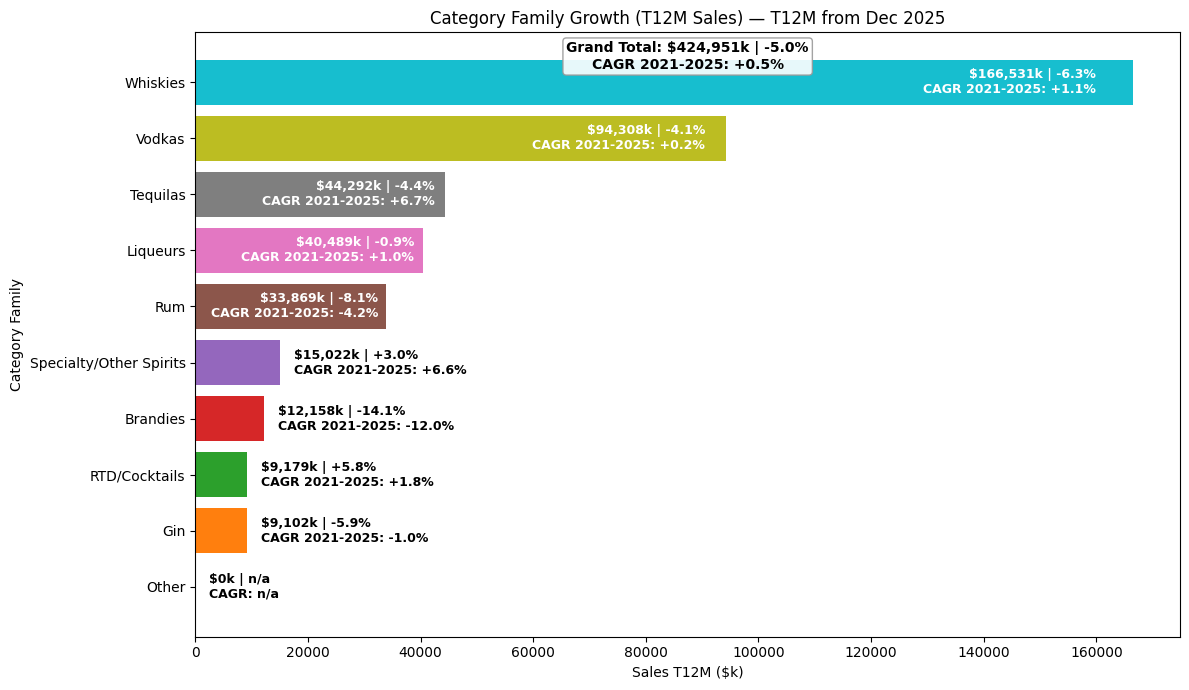

In [6]:
charts.plot_family_growth(df_family, params['month_start'], trend_years=params['trend_years'])

In [7]:
category_sql_template = nh.read_sql(root, 'analysis/sql/category_family_drilldown.sql')
category_sql = nh.render_sql(
    category_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
)

df_category = nh.run_sql(engine, category_sql)

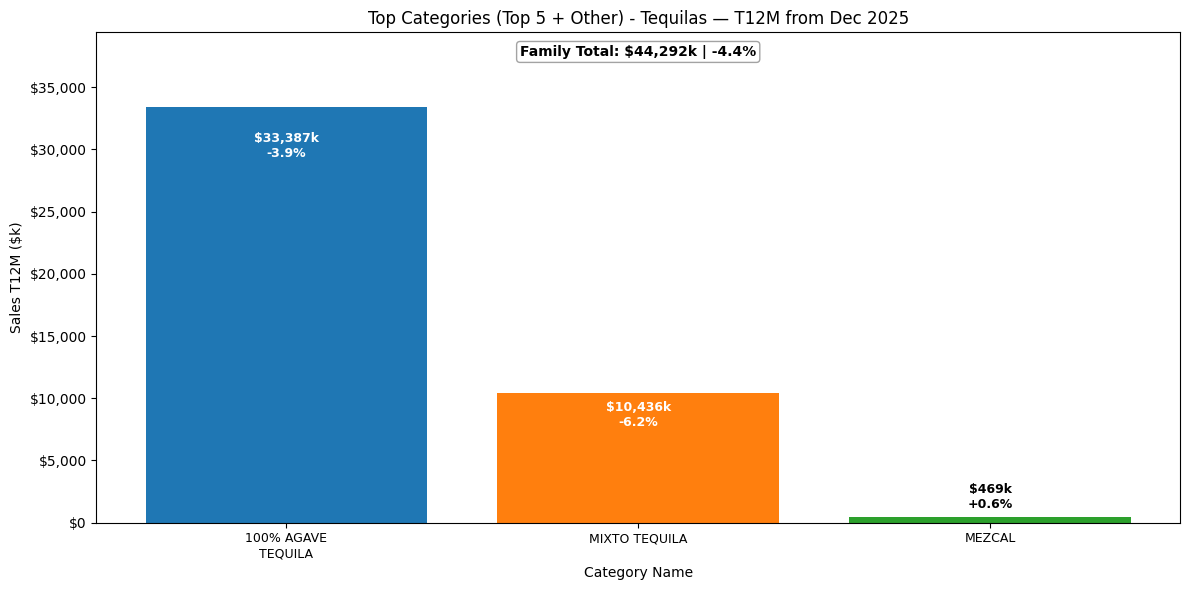

In [8]:
charts.plot_category_chart(df_category, params['category_family'], params['month_start'])

## Vendor Share Evolution

With category context established, we now examine how vendor leadership has shifted 
over the analysis period.

The donut charts below compare trailing 12-month vendor share in FY2021 vs. FY2025, 
alongside compound annual growth rates for the top three vendors.

### Key Question
How has vendor leadership changed — and is the shift structural or cyclical?

### Finding
Diageo moved from #3 to #1 in the tequila category, growing share from 14.6% to 23.4% 
over the period. This was not a single-year event. It was driven by a sustained CAGR 
of approximately +20%, compared to +5.5% for Proximo and -6.0% for Bacardi.

### Implication
The shift in leadership reflects sustained outperformance over multiple years — not 
short-term volatility or a single product cycle. That distinction matters: structural 
share shifts are harder to reverse than cyclical ones.

## Tequila Segment Breakdown

Tequila is not a monolithic category. It segments into three distinct tiers:

- **100% Agave** — premium positioning, Don Julio, Casamigos, Patrón
- **Mixto** — higher-volume, lower price point, Jose Cuervo Especial
- **Mezcal** — niche and emerging, small but growing

### Key Question
Where is growth concentrated within tequila — and does the premium segment 
drive the category or follow it?

### Finding
100% agave dominates category sales and accounts for the majority of revenue. 
Mixto remains significant in volume terms but has declined as a share of the category. 
Mezcal remains niche.

### Implication
Competitive dynamics within tequila are largely determined within the 100% agave 
segment. Vendor performance in mixto and mezcal matters at the margin — but the 
premium segment is where category leadership is won or lost.

In [9]:
vendor_trend_sql_template = nh.read_sql(root, 'analysis/sql/category_vendor_monthly_trend.sql')
vendor_trend_sql = nh.render_sql(
    vendor_trend_sql_template,
    window_start=trend_window['window_start'],
    window_end=trend_window['window_end'],
    category_family=params['category_family'],
    top_n_vendors=3,
)

df_vendor_trend = nh.run_sql(engine, vendor_trend_sql)


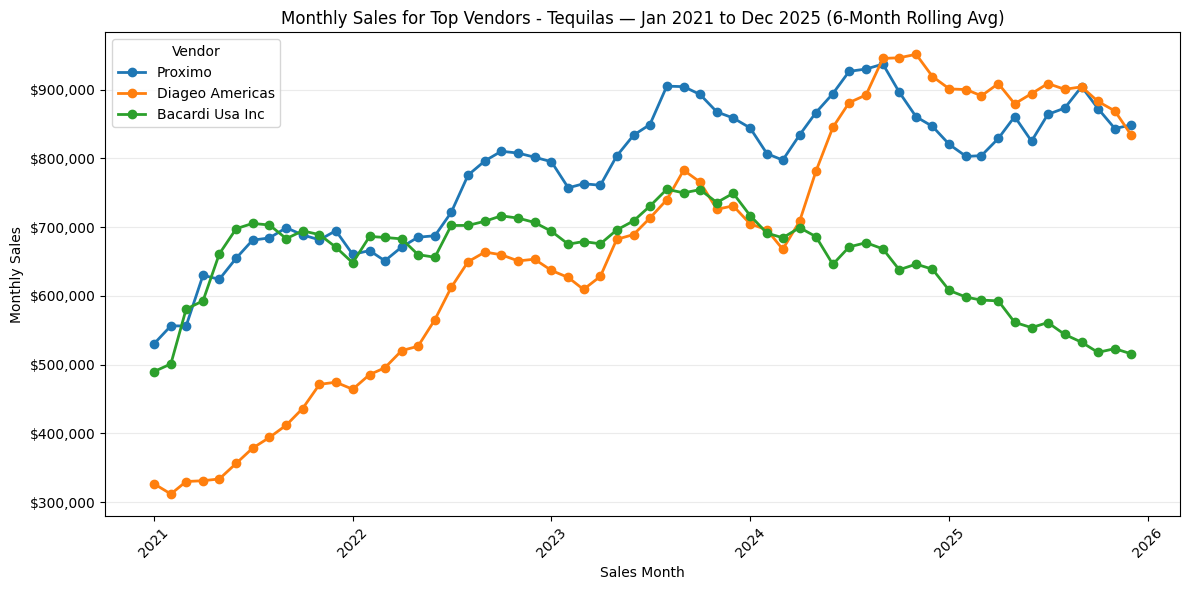

In [10]:
charts.plot_vendor_category_monthly_trend(
    df_vendor_trend,
    params['category_family'],
    window_start=trend_window['window_start'],
    window_end=trend_window['window_end'],
    smoothing_months=params.get('trend_smoothing_months', 3),
)


In [11]:
category_name_vendor_trend_sql_template = nh.read_sql(root, 'analysis/sql/category_name_vendor_monthly_trend.sql')
category_name_vendor_trend_sql = nh.render_sql(
    category_name_vendor_trend_sql_template,
    window_start=trend_window['window_start'],
    window_end=trend_window['window_end'],
    category_name=params['category_name'],
    top_n_vendors=3,
)

df_category_name_vendor_trend = nh.run_sql(engine, category_name_vendor_trend_sql)


In [12]:
family_vendor_share_3y_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_share_3y.sql')
family_vendor_share_3y_sql = nh.render_sql(
    family_vendor_share_3y_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    trend_years=params['trend_years'],
)

df_family_vendor_share_3y = nh.run_sql(engine, family_vendor_share_3y_sql)


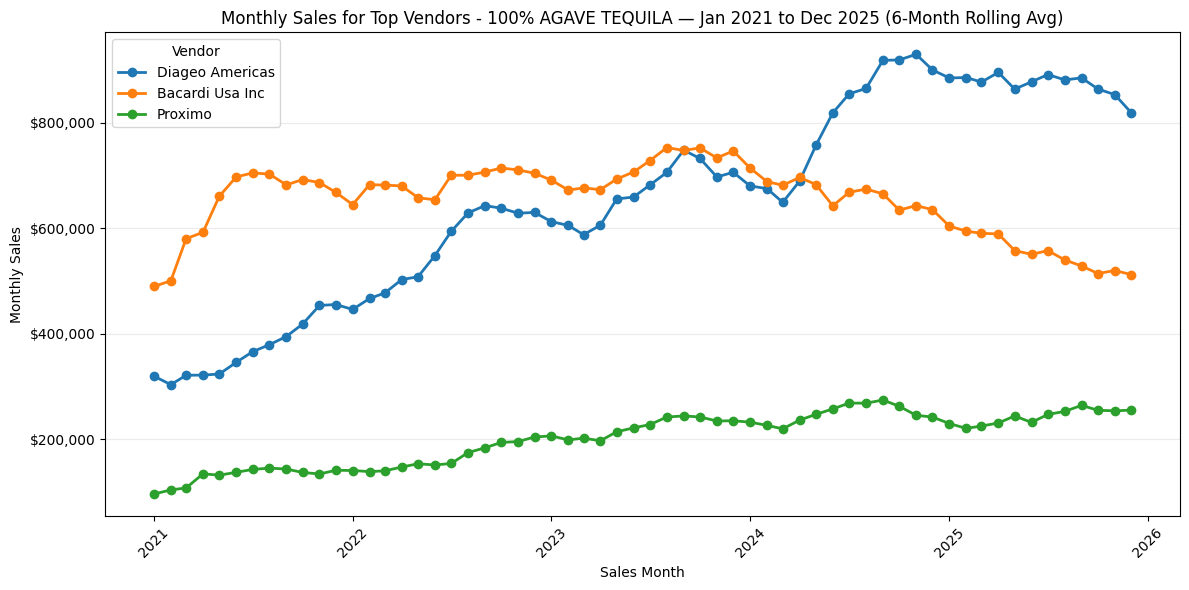

In [13]:
charts.plot_vendor_category_monthly_trend(
    df_category_name_vendor_trend,
    params['category_name'],
    window_start=trend_window['window_start'],
    window_end=trend_window['window_end'],
    smoothing_months=params.get('trend_smoothing_months', 3),
)


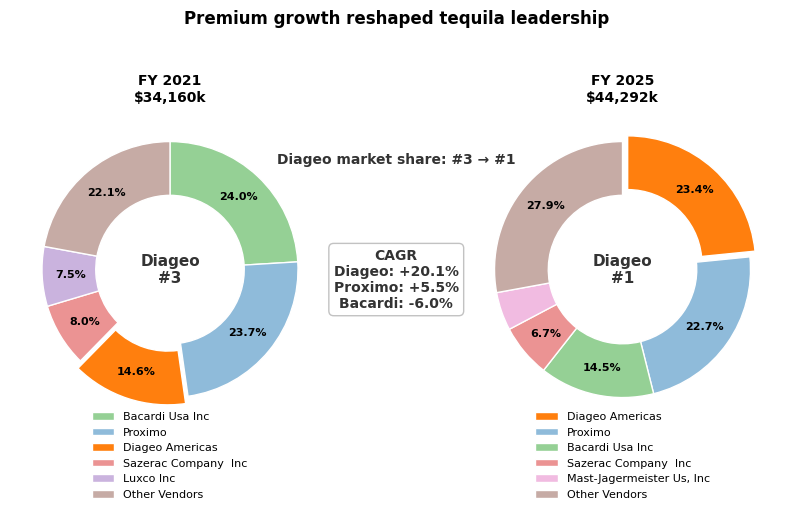

In [14]:
charts.plot_vendor_share_donuts_3y(
    df_family_vendor_share_3y,
    params['category_family'],
    params['month_start'],
    top_n_vendors=5,
    title_override='Premium growth reshaped tequila leadership', 
)


## Vendor Growth Rates (2021–2025)

To understand why share shifted, we examine CAGR across the top three vendors 
over the full analysis window.

### Finding
- **Diageo: ~+20% CAGR** — sustained outperformance across the period
- **Proximo: ~+5.5% CAGR** — steady growth, below category average
- **Bacardi: ~-6.0% CAGR** — consistent decline in both revenue and pricing power

### Insight
Diageo didn't just gain share — it compounded faster than every major competitor 
across the full five-year window. The gap between Diageo and Bacardi is not a 
story of one strong year. It is a story of consistent divergence.

### Implication
Sustained outperformance at this rate, over this duration, represents a structural 
shift in category leadership — not a temporary reordering. Understanding what drove 
that divergence requires looking beneath the revenue line.

In [15]:
family_vendor_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_growth.sql')
family_vendor_sql = nh.render_sql(
    family_vendor_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
)

df_family_vendor = nh.run_sql(engine, family_vendor_sql)


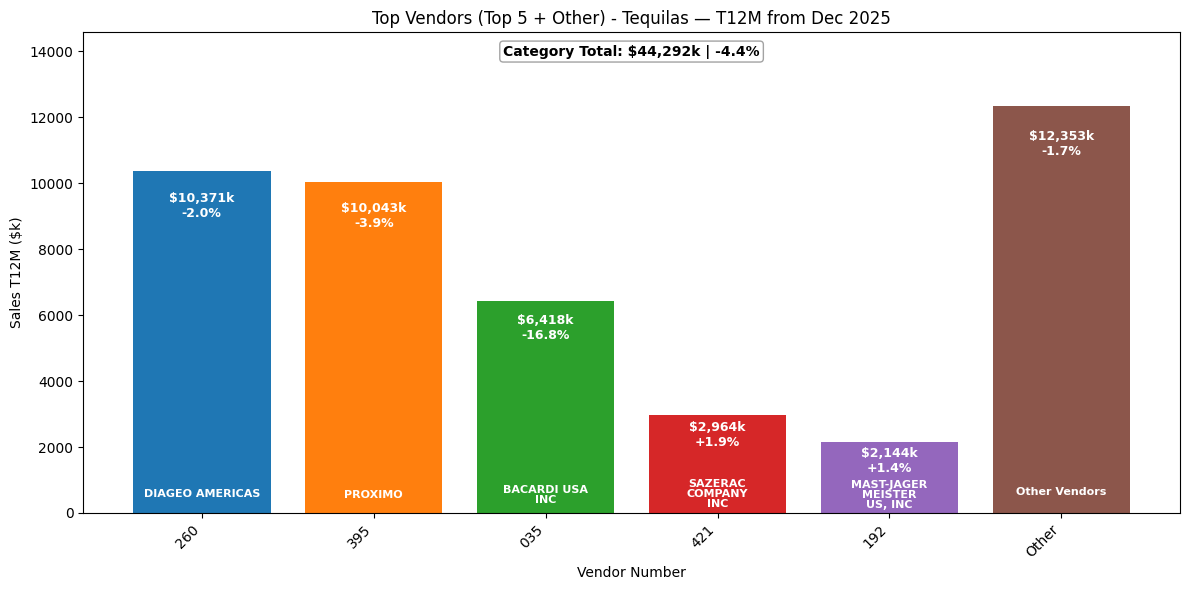

In [16]:
charts.plot_vendor_chart(df_family_vendor, params['category_family'], params['month_start'])


In [17]:
family_vendor_category_mix_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_category_mix.sql')
family_vendor_category_mix_sql = nh.render_sql(
    family_vendor_category_mix_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
)

df_family_vendor_category_mix = nh.run_sql(engine, family_vendor_category_mix_sql)


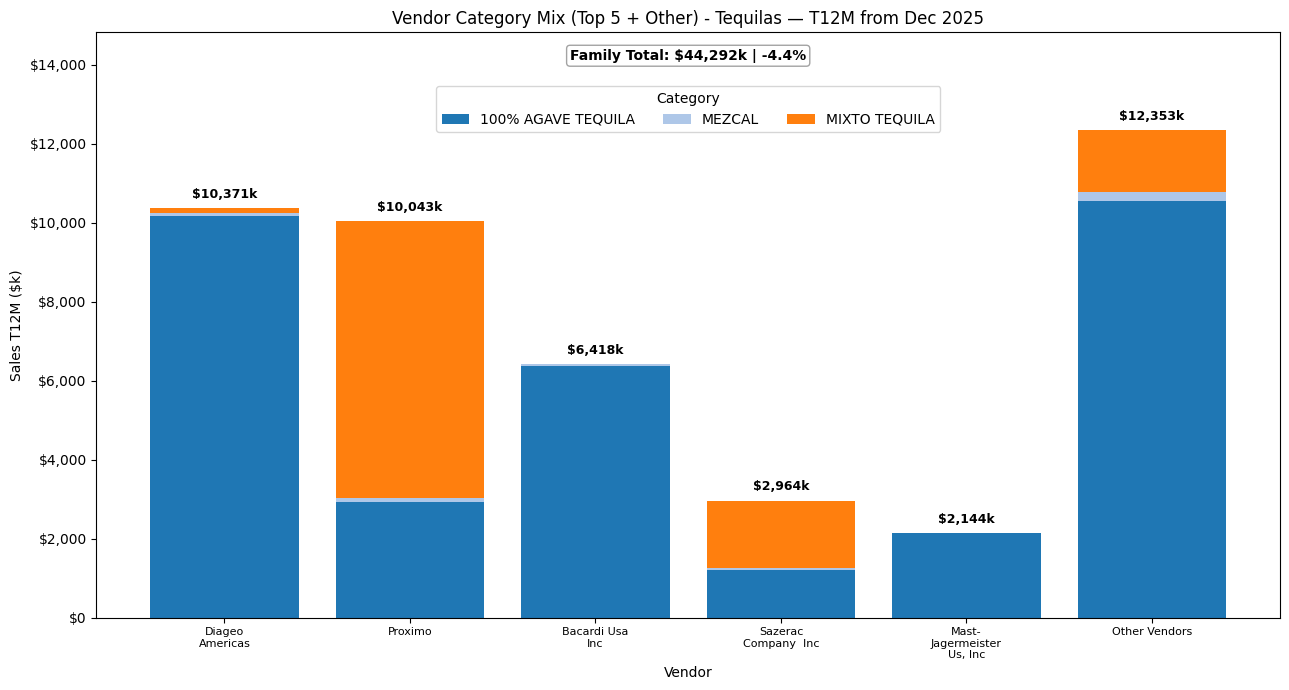

In [18]:
charts.plot_vendor_stacked_category_chart(
    df_family_vendor_category_mix,
    params['category_family'],
    params['month_start'],
    top_n_vendors=5,
)


In [19]:
family_vendor_price_segment_mix_grouped_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_price_segment_mix_grouped.sql')
family_vendor_price_segment_mix_grouped_sql = nh.render_sql(
    family_vendor_price_segment_mix_grouped_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    package_size_tier='',
)

df_family_vendor_price_segment_mix_grouped = nh.run_sql(engine, family_vendor_price_segment_mix_grouped_sql)


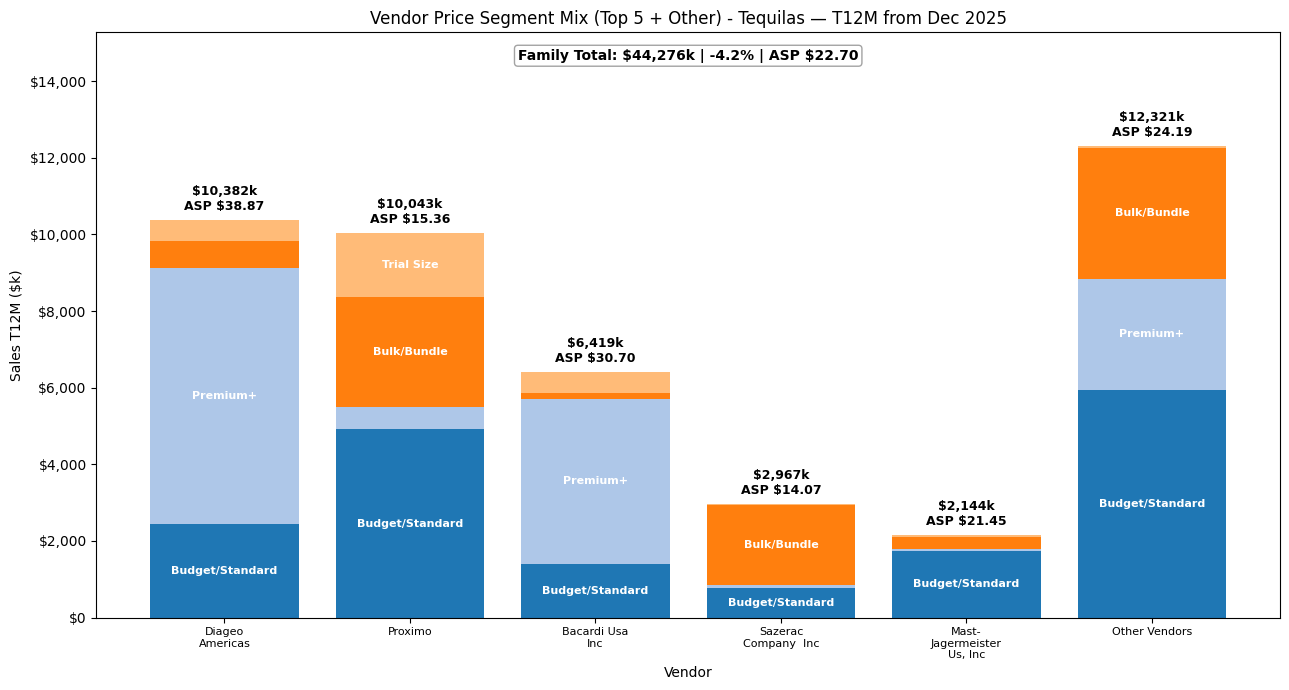

In [20]:
charts.plot_vendor_stacked_price_segment_chart(
    df_family_vendor_price_segment_mix_grouped,
    params['category_family'],
    params['month_start'],
    top_n_vendors=5,
)


In [21]:
family_vendor_price_segment_compare_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_price_segment_mix_compare.sql')
family_vendor_price_segment_compare_sql = nh.render_sql(
    family_vendor_price_segment_compare_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    package_size_tier='',
    trend_years=params['trend_years'],
)

df_family_vendor_price_segment_compare = nh.run_sql(engine, family_vendor_price_segment_compare_sql)


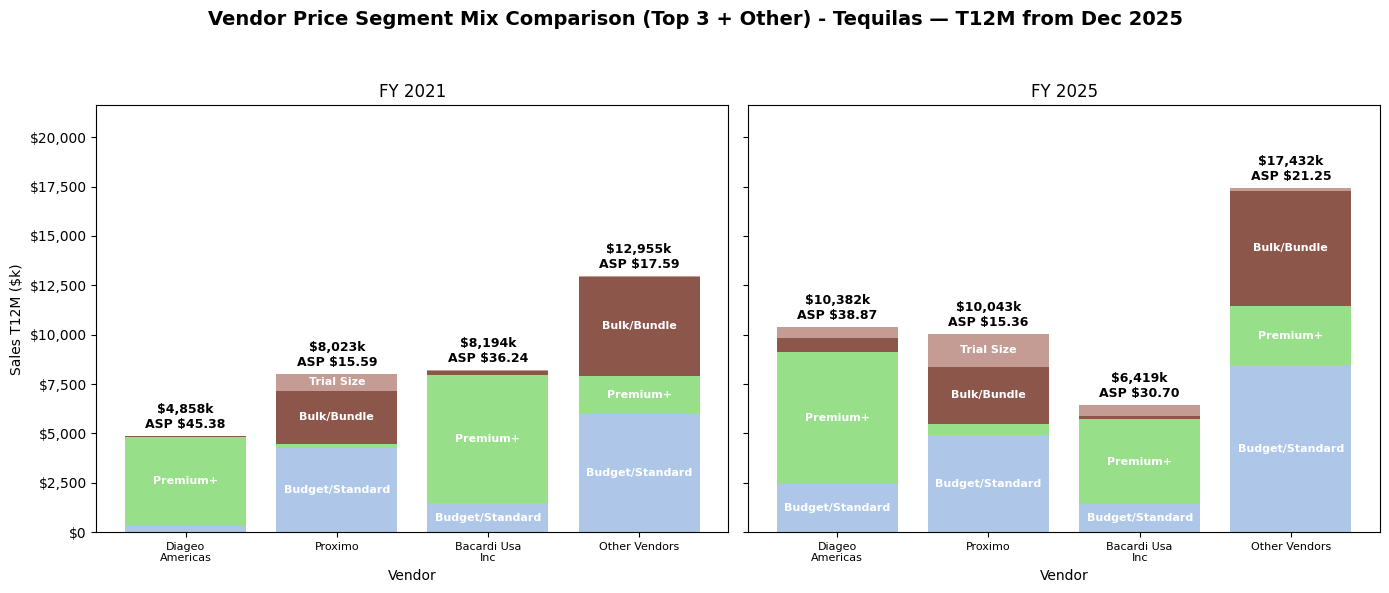

In [22]:
charts.plot_vendor_price_segment_compare(
    df_family_vendor_price_segment_compare,
    params['category_family'],
    params['month_start'],
)


In [23]:
family_vendor_price_segment_mix_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_price_segment_mix.sql')
family_vendor_price_segment_mix_sql = nh.render_sql(
    family_vendor_price_segment_mix_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    package_size_tier='',
)

df_family_vendor_price_segment_mix = nh.run_sql(engine, family_vendor_price_segment_mix_sql)


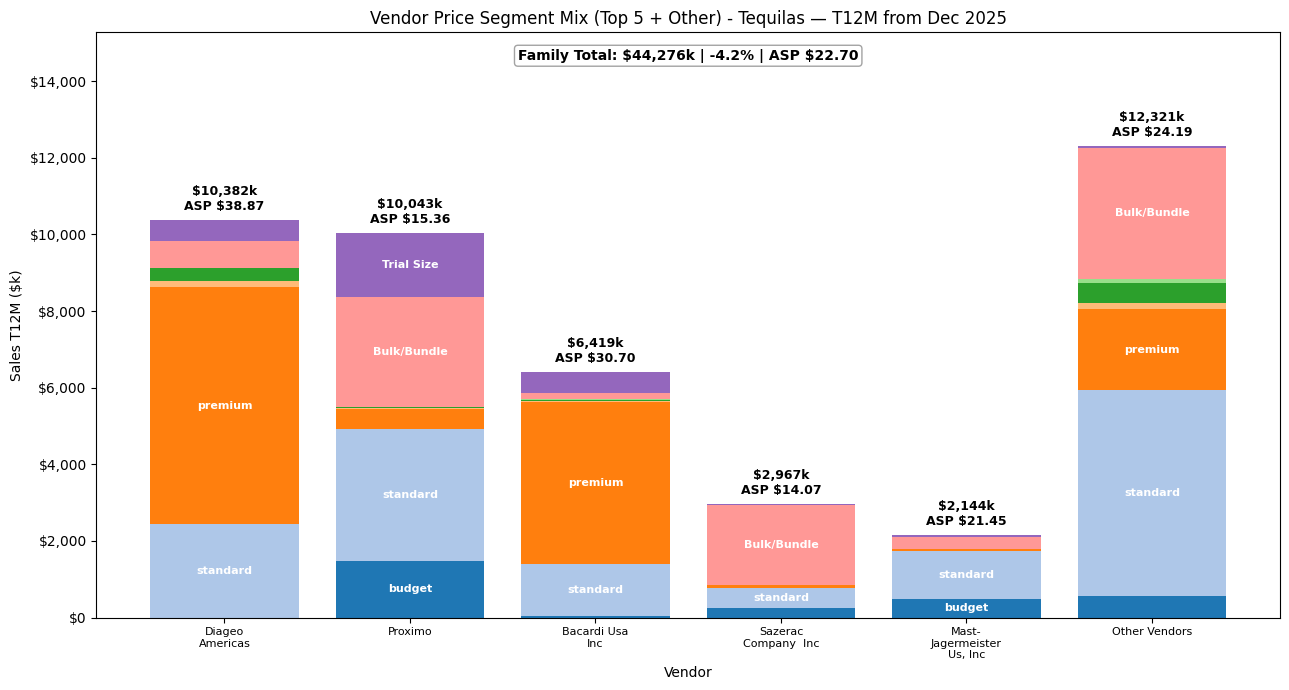

In [24]:
charts.plot_vendor_stacked_price_segment_chart(
    df_family_vendor_price_segment_mix,
    params['category_family'],
    params['month_start'],
    top_n_vendors=5,
)


## Price Segment Mix by Vendor

Revenue and share tell us what happened. Price segment mix begins to explain why.

This view classifies each vendor's sales into price position segments — derived from 
a custom dimension that combines bottle retail price, price per 100ml, and package 
format. Tier definitions are consistent with industry convention (Value, Standard, 
Premium, Super Premium, Ultra Premium, Luxury), with naming adapted for clarity. 
Bundle and trial formats are classified separately as format-based segments rather 
than price tiers.

### Key Question
How is revenue distributed across price tiers — and what does portfolio architecture 
reveal about each vendor's competitive strategy?

### Observations

**Diageo (ASP $38.87)**
Concentrated in premium and above, with meaningful presence across super premium 
and ultra premium tiers. Revenue more than doubled while ASP declined only modestly 
from $45.38 — indicating portfolio expansion rather than price dilution. Diageo grew 
by broadening depth within premium across Blanco, Reposado, and Añejo expressions 
under both Don Julio and Casamigos.

**Bacardi (ASP $30.70)**
Also positioned in premium, but with a narrower mix and a more significant ASP 
decline from $36.24. Revenue contracted from $8.2M to $6.4M. Bacardi lost ground 
on both volume and pricing power simultaneously — a structurally weak outcome for 
a brand concentrated in a single premium franchise.

**Proximo (ASP $15.36)**
Operates across a different part of the price architecture. Proximo expanded 
accessibility during the period — adding trial size formats on top of existing 
mid-tier segments without meaningfully cannibalizing their core. This reflects 
a strategy of broadening the entry point rather than repositioning upward.

**Other Vendors (~35% of category sales, ASP $21.25)**
The long tail of the category remains anchored in mass and mid tiers, with 
significant bulk and bundle presence. The long tail is not premiumizing at 
the same rate as the top vendors — which means category-level growth is 
being driven by the top of the competitive set, not the shelf broadly.

### Core Insight
The category is not simply premium vs. value.

It is structured across:
- **Price architecture** — where a vendor competes on the value ladder
- **Portfolio depth** — how many occasions and price points they can capture within a tier
- **Purchase accessibility** — how easy it is for a new or casual consumer to enter

These dimensions — not price alone — determine how share is won.

### Implication
Pricing is not just a reflection of positioning — it is a structural driver of 
how share is won. The vendors that grew during this period did so by expanding 
their portfolio architecture, not by defending a single price point.

In [25]:
detail_sql_template = nh.read_sql(root, 'analysis/sql/category_vendor_volume_growth.sql')
detail_sql = nh.render_sql(
    detail_sql_template,
    month_start=params['month_start'],
    category_name=params['category_name'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_detail = nh.run_sql(engine, detail_sql)

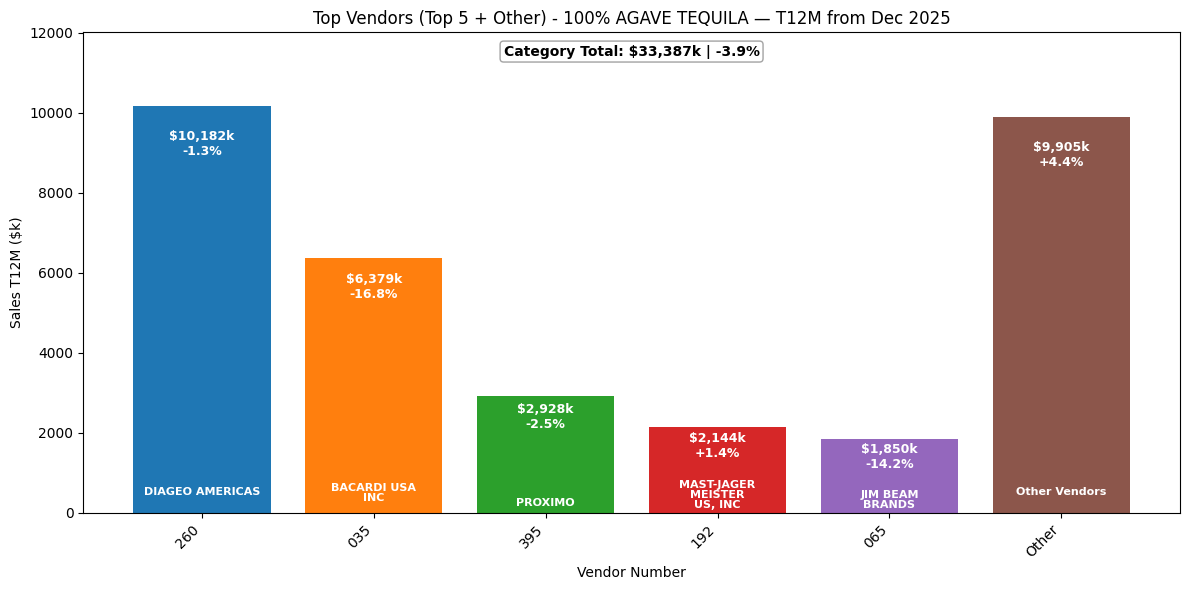

In [26]:
charts.plot_vendor_chart(df_detail, params['category_name'], params['month_start'])

In [27]:
detail_sql_2 = nh.render_sql(
    detail_sql_template,
    month_start=params['month_start'],
    category_name=params['category_name2'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_detail_2 = nh.run_sql(engine, detail_sql_2)


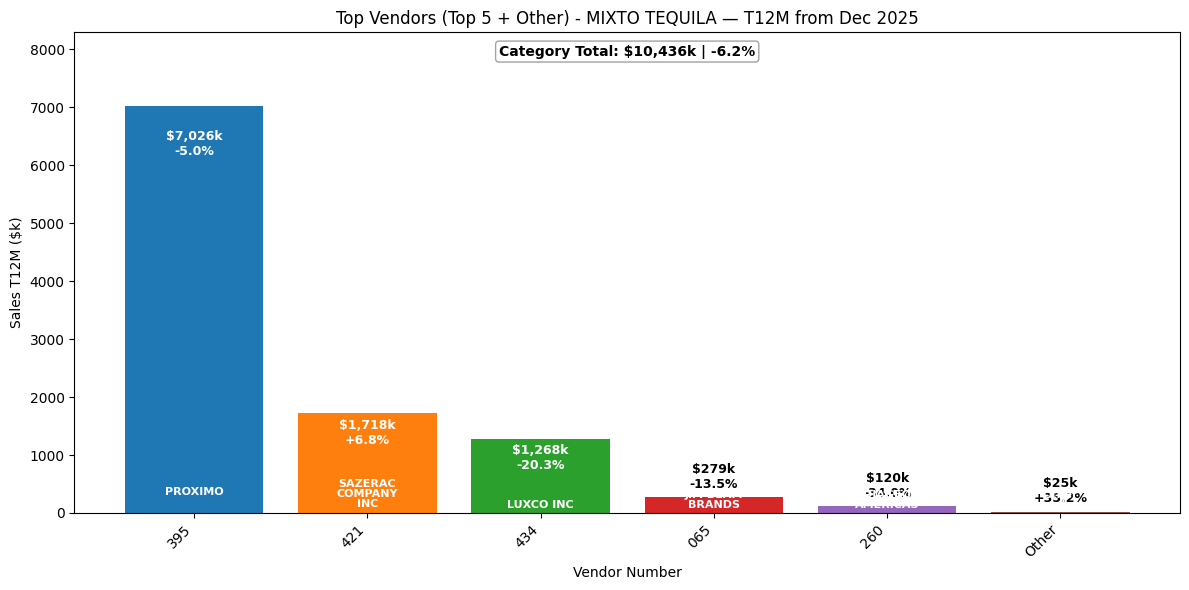

In [28]:
charts.plot_vendor_chart(df_detail_2, params['category_name2'], params['month_start'])


In [29]:
item_sql_template = nh.read_sql(root, 'analysis/sql/category_item_growth.sql')
item_sql = nh.render_sql(
    item_sql_template,
    month_start=params['month_start'],
    category_name=params['category_name'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_item = nh.run_sql(engine, item_sql)

In [30]:
family_item_sql_template = nh.read_sql(root, 'analysis/sql/category_family_item_growth.sql')
family_item_sql = nh.render_sql(
    family_item_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_family_item = nh.run_sql(engine, family_item_sql)


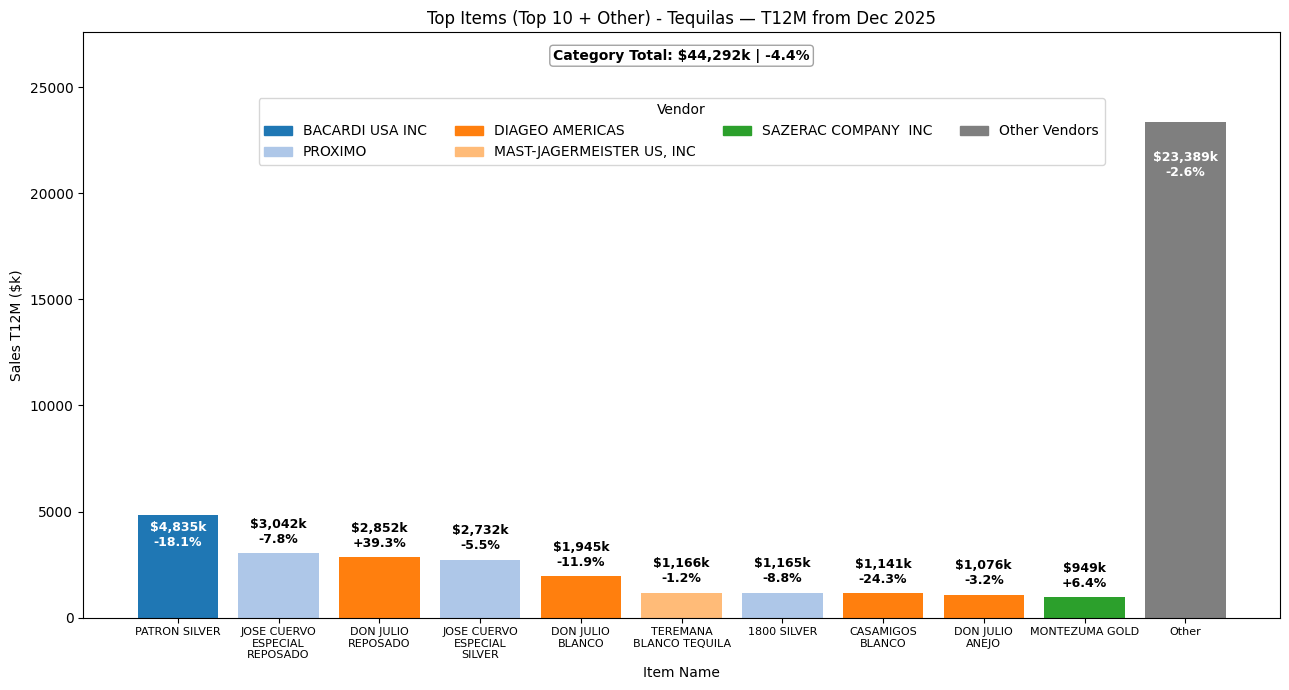

In [31]:
charts.plot_item_chart(df_family_item, params['category_family'], params['month_start'], top_n=10)


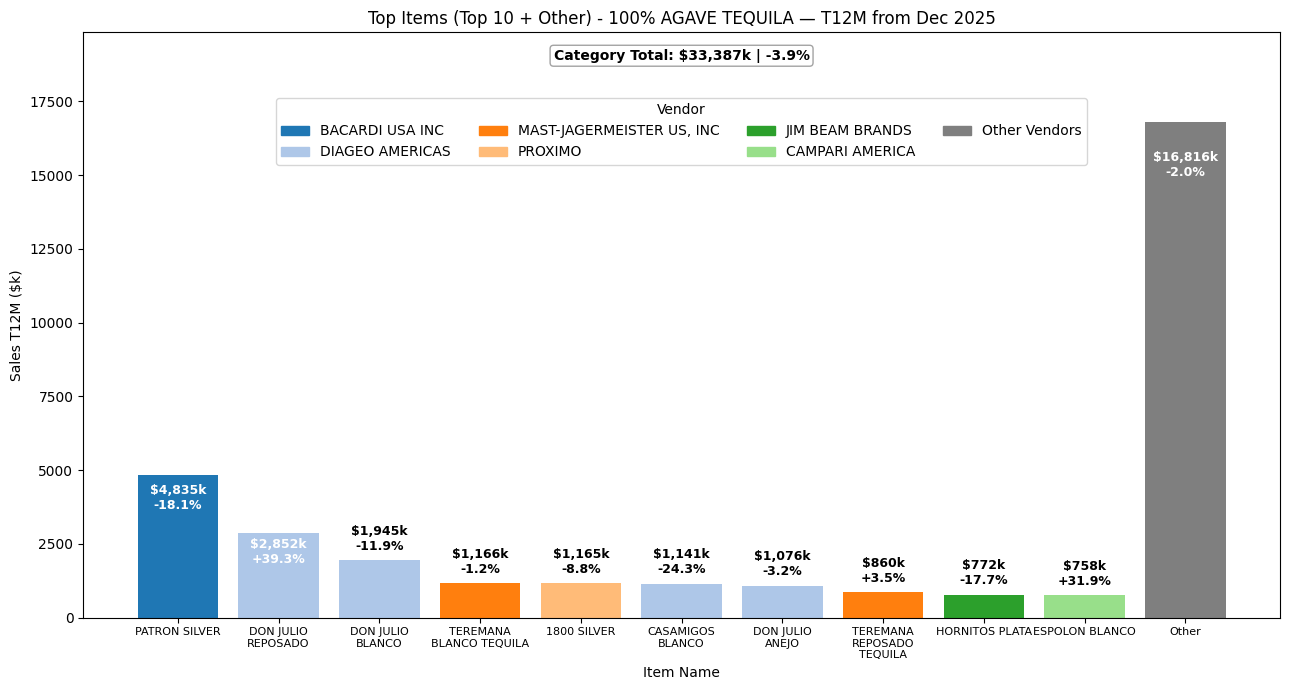

In [32]:
charts.plot_item_chart(df_item, params['category_name'], params['month_start'], top_n=10)

In [33]:
item_sql_2 = nh.render_sql(
    item_sql_template,
    month_start=params['month_start'],
    category_name=params['category_name2'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_item_2 = nh.run_sql(engine, item_sql_2)


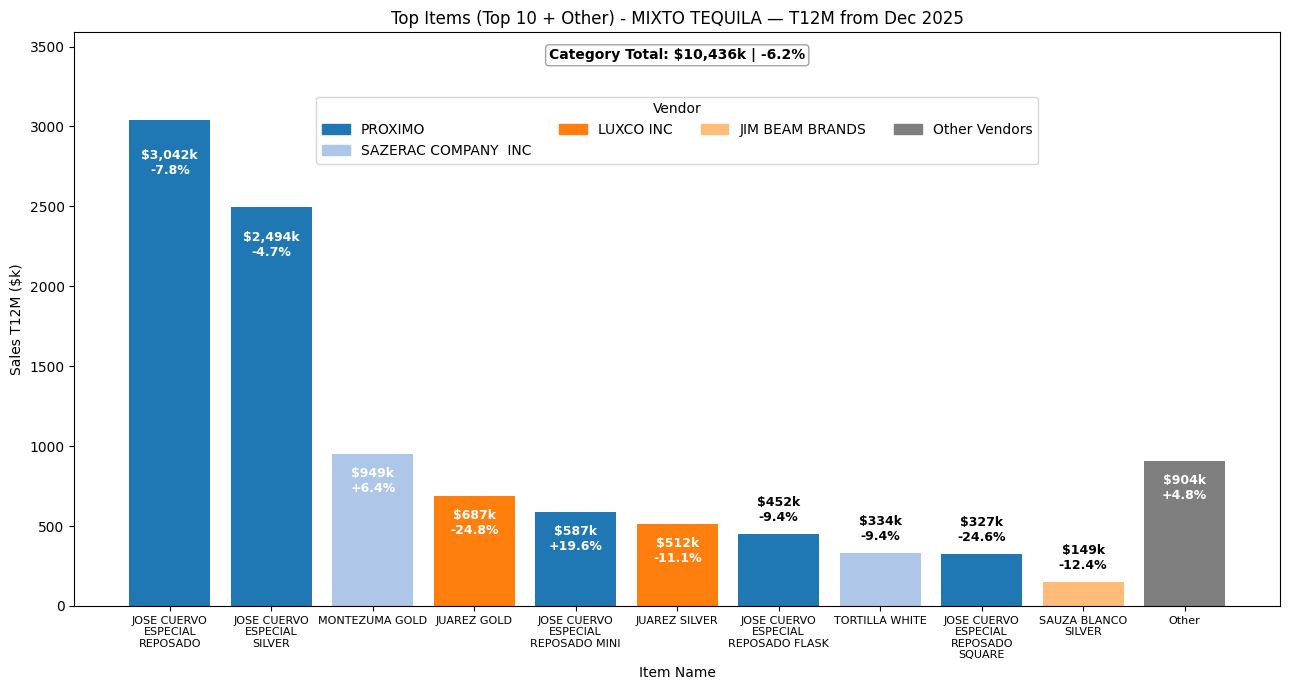

In [34]:
charts.plot_item_chart(df_item_2, params['category_name2'], params['month_start'], top_n=10)


## Strategic Interpretation

The vendor growth data raises a question that revenue alone cannot answer:

Why did Diageo outperform so consistently — and why did Bacardi underperform 
despite operating in the same premium segment?

### Observations

The difference is not premium vs. volume. Both Diageo and Bacardi are premium 
tequila businesses. The divergence comes from how premium is structured and executed.

- **Diageo** built portfolio depth across expressions (Blanco, Reposado, Añejo) 
  and brands (Don Julio, Casamigos), capturing more occasions and price points 
  within the premium tier
- **Bacardi** concentrated around a single franchise (Patrón) without meaningfully 
  expanding the portfolio architecture during the category's strongest growth window
- **Proximo** took a different path — scale through accessibility, broadening the 
  entry point rather than moving upmarket

### Insight
Portfolio depth allows a vendor to capture demand across more occasions, consumer 
types, and price points within a tier. A single franchise — however strong — creates 
concentration risk when the category moves.

### Implication
Growth is driven not just by where you are positioned, but by how that positioning 
is structured. The vendors that compounded share during this period did so by 
giving consumers more ways to buy into their portfolio — not by defending a 
single product or price point.

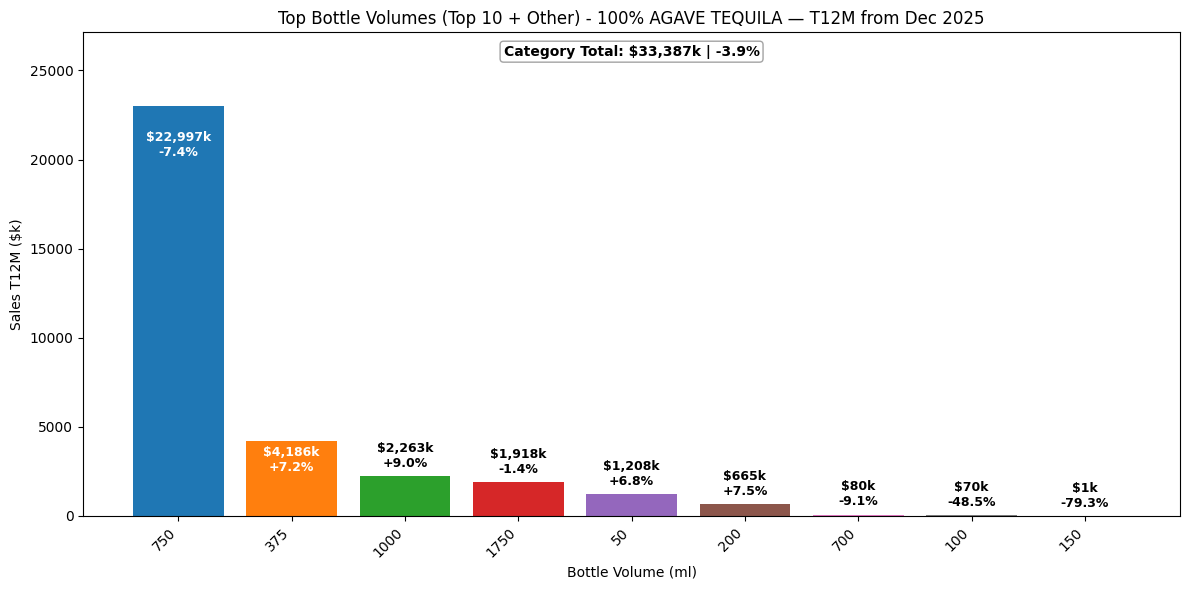

In [35]:
charts.plot_volume_chart(df_detail, params['category_name'], params['month_start'], top_n=10)

In [36]:
chain_sql_template = nh.read_sql(root, 'analysis/sql/category_chain_growth.sql')
chain_sql = nh.render_sql(
    chain_sql_template,
    month_start=params['month_start'],
    category_name=params['category_name'],
    vendor_number_filter=params['vendor_number_filter'],
    bottle_volume_ml_filter=params['bottle_volume_ml_filter'],
)

df_chain = nh.run_sql(engine, chain_sql)

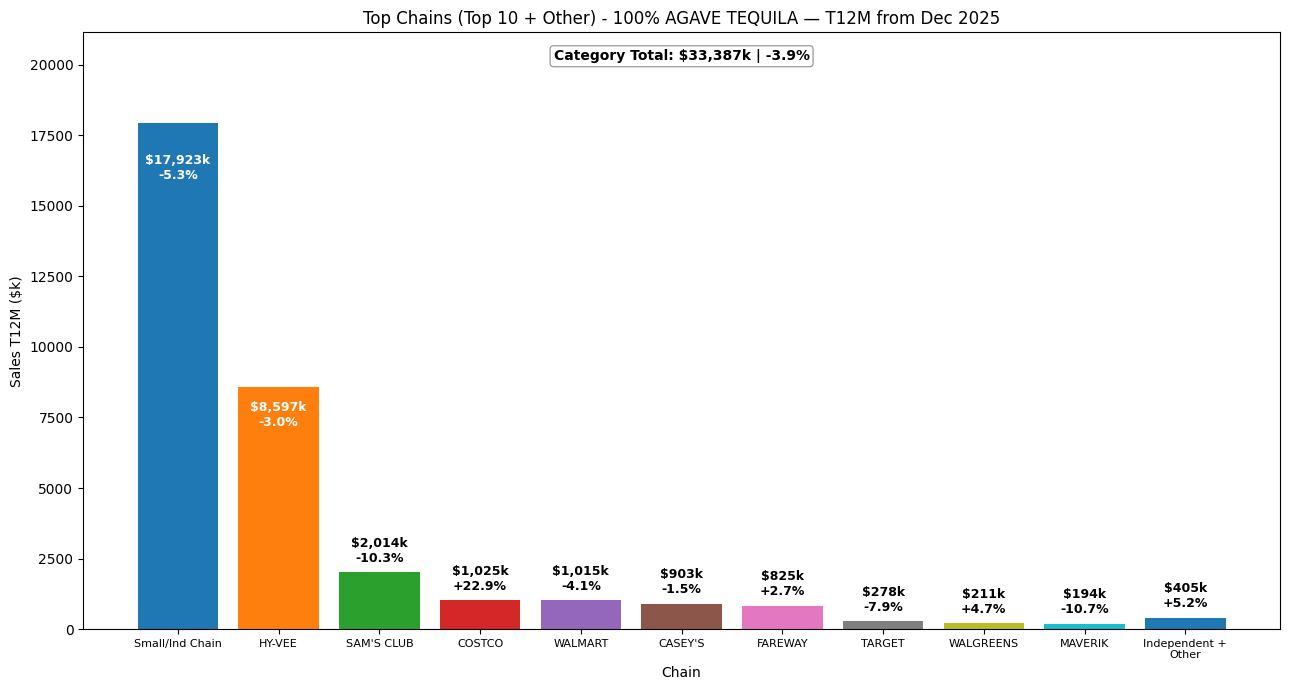

In [37]:
charts.plot_chain_chart(df_chain, params['category_name'], params['month_start'], top_n=10)

## Store Channel Mix by Vendor

Price segment mix reveals *what* vendors are selling. Store channel mix reveals *where* they are selling it — and the two are not independent.

Iowa's retail landscape is anchored by two dominant channels: Grocery and Liquor Store. Together they account for the majority of tequila sales. Convenience/Gas is a meaningful third channel, particularly for volume-oriented brands.

### Key Question
Does channel mix explain ASP differences across vendors — and does it reinforce or contradict the price segment story?

### Observations

**Diageo (Liquor Store 39% | $41.44 ASP)**
Diageo's strongest channel by ASP is Liquor Store — where Don Julio and Casamigos command a $6 premium over their already-elevated C-Gas ASP ($35.47). Their Grocery and C-Gas presence is real but secondary. This is a portfolio that earns its premium most efficiently where discovery and trade-up behavior is highest.

**Proximo (Uniform ASP across channels)**
ASP is flat across all channels — ~$13–16. This is a volume distribution strategy, not a channel-selective one. Jose Cuervo Especial sells wherever it can. Channel does not explain their ASP; price architecture does.

**Bacardi (Liquor Store 37% | $31.98 ASP)**
Bacardi follows a similar channel pattern to Diageo but at a materially lower ASP. The $10 gap between Diageo and Bacardi within the Liquor Store channel is not a channel effect — it reflects Diageo's deeper premium tier presence within the same retail environment.

**Sazerac (Warehouse/Club ASP > Liquor Store ASP)**
An apparent outlier: Warehouse/Club ASP ($19.47) exceeds Liquor Store ($12.71). This is a format effect — large-format 1.75L purchases at Costco and Sam's Club inflate dollar value per transaction without reflecting a premium price position. ASP here overstates positioning.

### Core Insight
Liquor Stores are the premium channel in Iowa. Across every vendor in this set, Liquor Store ASP is at or near the top of the channel range. This is consistent with how specialty off-premise retail behaves — higher shopper intent, broader SKU depth, and greater willingness to trade up.

Diageo's channel and price segment mix are mutually reinforcing: concentrated in Liquor Store *and* concentrated in premium tier. That combination — not either factor alone — explains their ASP premium.

### Implication
Where you sell determines what you can sell at. A vendor without Liquor Store presence has a structural ceiling on achievable ASP regardless of portfolio quality. Channel strategy and pricing strategy are not independent decisions.

In [38]:
family_vendor_store_channel_mix_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_store_channel_mix.sql')
family_vendor_store_channel_mix_sql = nh.render_sql(
    family_vendor_store_channel_mix_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
)

df_family_vendor_store_channel_mix = nh.run_sql(engine, family_vendor_store_channel_mix_sql)

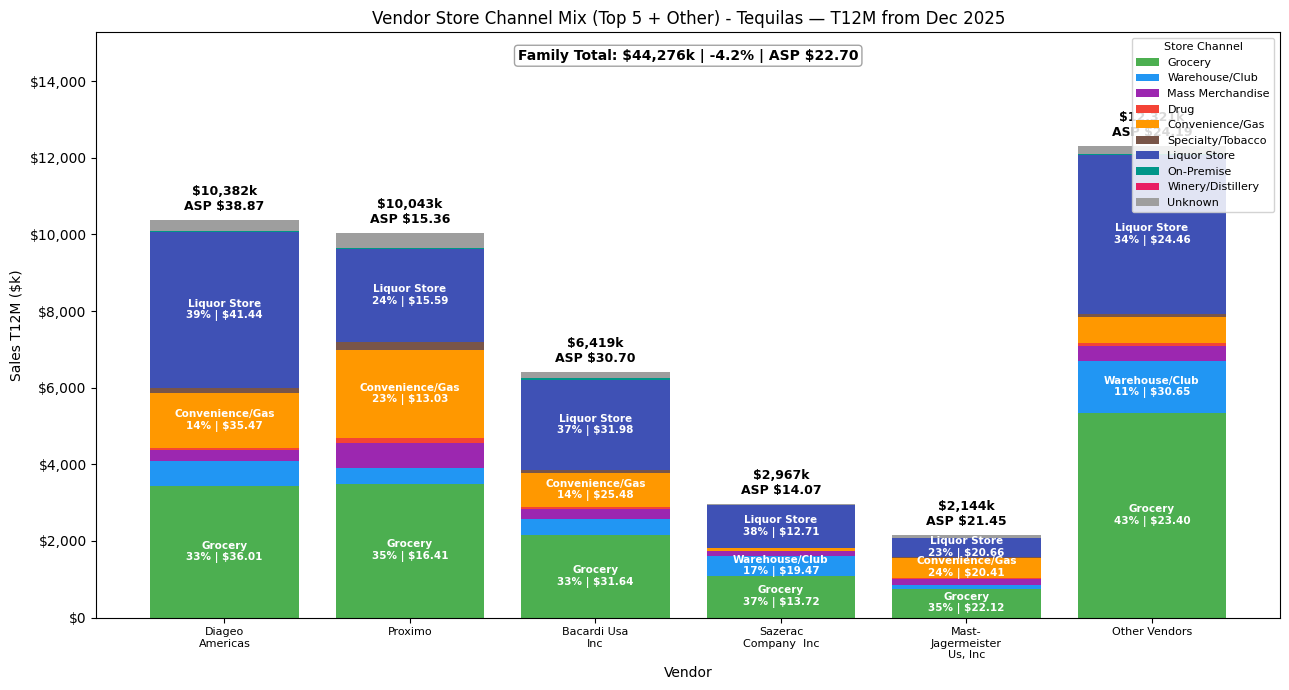

In [39]:
charts.plot_vendor_stacked_store_channel_chart(
    df_family_vendor_store_channel_mix,
    params['category_family'],
    params['month_start'],
    top_n_vendors=5,
)

### Did Channel Strategy Shift?

A natural follow-up question: did vendors win by expanding into new channels over the period — or was channel mix stable?

**Finding: No material channel shift across any major vendor (2021 → 2025).**

Channel composition is largely unchanged. Diageo was Grocery + Liquor Store in 2021 and remains so in 2025. Proximo's spread across Grocery, C-Gas, and Liquor Store is consistent across both periods. The bars grew — but the mix did not rotate.

This is an important negative result. The divergence in vendor outcomes was not driven by a channel strategy shift. Vendors did not win by moving into new channels. The explanation lies elsewhere — specifically, in what was sold *within* those channels, which the price segment mix analysis addresses directly.

In [40]:
family_vendor_store_channel_compare_sql_template = nh.read_sql(root, 'analysis/sql/category_family_vendor_store_channel_mix_compare.sql')
family_vendor_store_channel_compare_sql = nh.render_sql(
    family_vendor_store_channel_compare_sql_template,
    month_start=params['month_start'],
    category_family=params['category_family'],
    trend_years=params['trend_years'],
)

df_family_vendor_store_channel_compare = nh.run_sql(engine, family_vendor_store_channel_compare_sql)

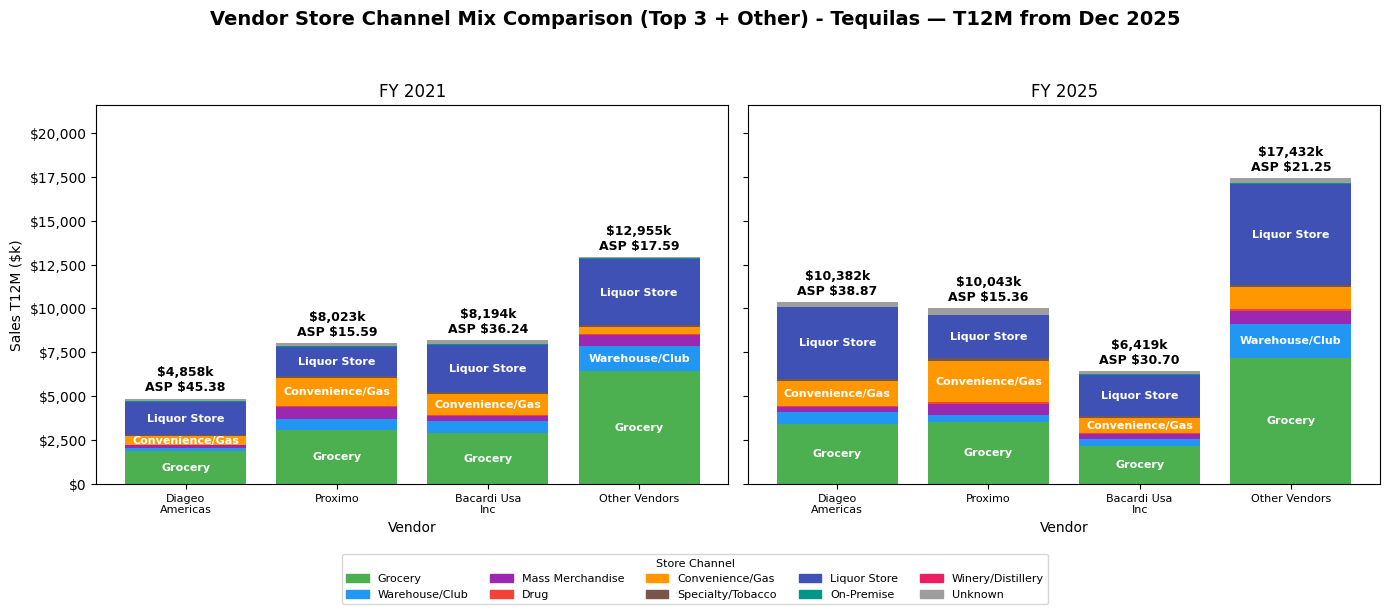

In [41]:
charts.plot_vendor_store_channel_compare(
    df_family_vendor_store_channel_compare,
    params['category_family'],
    params['month_start'],
)

## Final Takeaways

The tequila market between 2021 and 2025 tells a clear story — but only if you 
look beneath the surface.

At the category level, tequila was the strongest-performing major spirits segment 
over the period, growing from $34M to $44M in Iowa while the broader market softened. 
That growth, however, was not distributed evenly. It was concentrated at the top of 
the competitive set and within the premium tier — driven by vendors who used the 
category's strongest window to broaden their portfolio architecture.

Diageo's movement from #3 to #1 — with a +20% CAGR and share growth from 14.6% 
to 23.4% — was not a single-year event. It was the compounding result of portfolio 
depth, pricing discipline, and sustained outperformance across multiple expressions 
and brands. Revenue more than doubled while ASP declined only modestly, reflecting 
expansion rather than dilution.

Bacardi's outcome offers the clearest counterpoint. A recognized premium franchise 
in a growing premium category — and yet revenue contracted and pricing power eroded 
simultaneously. Concentration without breadth is a structural liability when the 
category is moving and competitors are expanding.

Proximo held its position through a different strategy — broadening accessibility 
rather than moving upmarket. Trial size expansion without cannibalizing the core 
reflects a disciplined approach to lowering the barrier to entry across formats 
and occasions.

The category did not shift randomly.

It shifted because:

- Premium portfolios expanded depth — Diageo
- Value strategies expanded access — Proximo
- Concentrated strategies lost ground — Bacardi

The macro environment has shifted since. Premium is showing pressure and the 
broader category has softened. Whether Diageo's portfolio depth protects them 
through the next cycle — or whether the market reordering continues — remains 
the question worth watching.

---

This analysis demonstrates what becomes possible when data is modeled at the 
right grain. Category families, store chains, and price position segments were 
all engineered from a dataset with limited native dimensions — built once, 
reused across every view in this notebook.

The system supports the analysis.

The analysis surfaces the story.

The charts are not the output.

The story is.